# AI ASSISTED WORK under human supervision and edit trust

## Cus im not good at physics YET

---

## import libraries

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [119]:
d = pd.read_csv("tfirst_bounce.csv")  

print(d.head())

       time        xm        ym
0  0.000000  0.496650  0.019352
1  0.002252  0.496602  0.026899
2  0.004505  0.496554  0.034445
3  0.006757  0.496505  0.041992
4  0.009009  0.496457  0.049539


In [120]:
d_trimmed = d[(d['time'] >= 0.05) & (d['time'] <= 0.65)]  # adjust bounds based on raw plot
coeffs_y = np.polyfit(d_trimmed['time'], d_trimmed['ym'], 2)
a, viy, yi = coeffs_y
g_fit = -2*a
print(g_fit)

16.983254742521957


## Equation functions

In [121]:
g = 9.81
scale = 0.001451 #m/px

In [122]:
def xt(xi, vix, t):
    return xi + vix * t

def yt(yi, viy, t, g):
    return yi + viy * t - 0.5 * g * (t**2)

def vxt(vix):
    return vix

def vyt(viy, t, g):
    return viy - g * t

def speed(vx, vy):
    return np.sqrt(vx**2 + vy**2)

def peak_height_ideal(yi, viy, g):
    return yi + (viy**2) / (2*g)

def flight_time_ideal(yi, viy, g):
    return (viy + np.sqrt(viy**2 + 2*g*yi)) / g

def deviation(y_actual, y_ideal):
    return y_actual - y_ideal

## Fitting data to get real conditions (values to use)

In [123]:
coeffs_y = np.polyfit(d['time'], d['ym'], 2)
a, viy, yi = coeffs_y

coeffs_x = np.polyfit(d['time'], d['xm'], 1)
vix, xi = coeffs_x

g_fit = -2 * a
print(f"g from fit: {g_fit:.3f} (expect close to 9.81)")
print(f"v0y: {viy:.3f} m/s, v0x: {vix:.3f} m/s")
print(f"y0: {yi:.3f} m, x0: {xi:.3f} m")

g from fit: 16.000 (expect close to 9.81)
v0y: 5.715 m/s, v0x: 0.498 m/s
y0: -0.050 m, x0: 0.439 m


## ideal (no drag) curve using the same conditions

In [124]:
t = d['time']
y_ideal = yt(yi, viy, t, g)
x_ideal = xt(xi, vix, t)

## Comparison 

In [125]:
y_max_actual = d['ym'].max()
y_max_ideal = peak_height_ideal(yi, viy, g)

t_flight_ideal = flight_time_ideal(yi, viy, g)
t_flight_actual = d['time'].max()

dev = deviation(d['ym'], y_ideal)

print(f"Peak height - actual: {y_max_actual:.3f} m --> ideal: {y_max_ideal:.3f} m")
print(f"Flight time - actual: {t_flight_actual:.3f} s --> ideal: {t_flight_ideal:.3f} s")
print(f"Max deviation: {dev.abs().max():.4f} m")

Peak height - actual: 0.993 m --> ideal: 1.615 m
Flight time - actual: 0.718 s --> ideal: 1.156 s
Max deviation: 1.5242 m


## Graphs

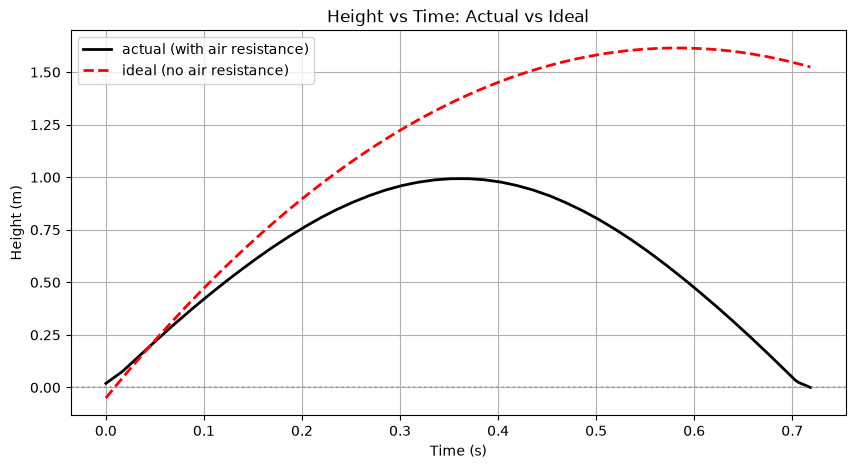

In [126]:
plt.figure(figsize=(10, 5))
plt.plot(d['time'], d['ym'], color='black', linewidth=2, label='actual (with air resistance)')
plt.plot(t, y_ideal, color='red', linewidth=2, linestyle='--', label='ideal (no air resistance)')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Height vs Time: Actual vs Ideal')
plt.legend()
plt.grid()
plt.show()

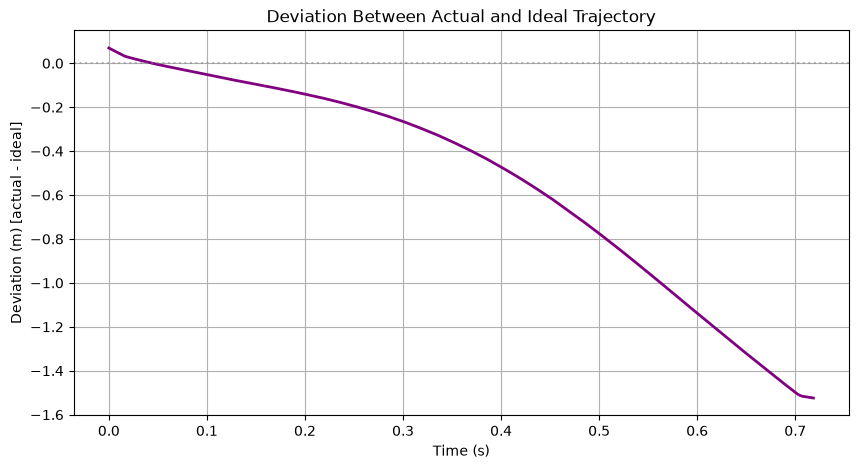

In [127]:
# deviation vs time
plt.figure(figsize=(10, 5))
plt.plot(d['time'], dev, color='purple', linewidth=2)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Deviation (m) [actual - ideal]')
plt.title('Deviation Between Actual and Ideal Trajectory')
plt.grid()
plt.show()

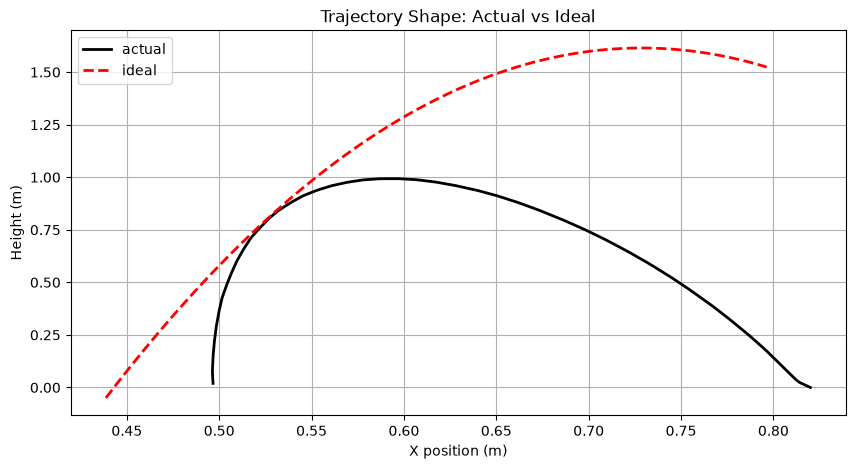

In [128]:
plt.figure(figsize=(10, 5))
plt.plot(d['xm'], d['ym'], color='black', linewidth=2, label='actual')
plt.plot(x_ideal, y_ideal, color='red', linewidth=2, linestyle='--', label='ideal')
plt.xlabel('X position (m)')
plt.ylabel('Height (m)')
plt.title('Trajectory Shape: Actual vs Ideal')
plt.legend()
plt.grid()
plt.show()

## Compare

In [129]:
print(r2_score(y_ideal, d['ym']))

-1.1048222828341014


## LENS DISTORTION

using wide angle lens with a target moving across frame caused the camera to severely distort the image and thus limiting the accuracy of the model, shown in x and y residuals, the double parabolas + the inaccurate gravity calc earlier.

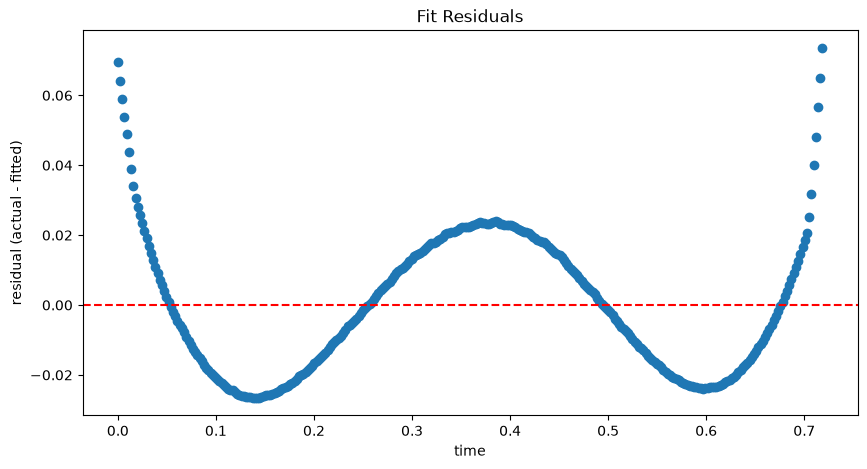

In [130]:
residuals = d['ym'] - yt(yi, viy, d['time'], g_fit)
plt.figure(figsize=(10,5))
plt.scatter(d['time'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('time')
plt.ylabel('residual (actual - fitted)')
plt.title('Fit Residuals')
plt.show()

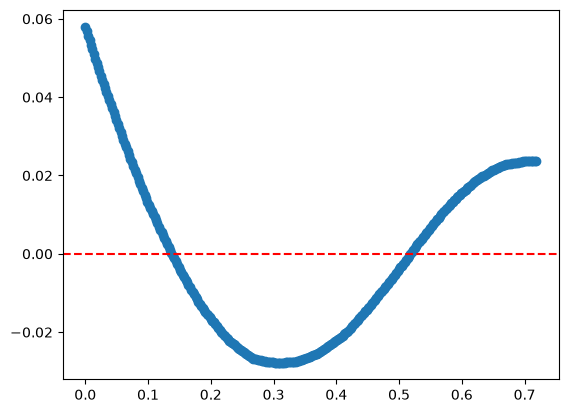

In [131]:
residuals_x = d['xm'] - xt(xi, vix, d['time'])
plt.scatter(d['time'], residuals_x)
plt.axhline(0, color='red', linestyle='--')
plt.show()